In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load data
df = pd.read_csv("../data/cleaned/wednesday_cleaned.csv")

# Get all numeric columns (exclude Label and Attack)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in ['Attack']]

print(f"\nNumeric features to standardize: {len(numeric_cols)}")

# Standardize the numeric columns
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[numeric_cols])

# Convert back to DataFrame with column names
df_standardized = pd.DataFrame(df_scaled, columns=numeric_cols)

# Add back the target column
df_standardized['Attack'] = df['Attack'].values

print("\nFirst few rows:")
print(df_standardized.head())



Numeric features to standardize: 67

First few rows:
   Destination_Port  Flow_Duration  Total_Fwd_Packets  Total_Backward_Packets  \
0         -0.055155      -0.980633          -0.068553               -0.033973   
1         -0.055155      -0.982667          -0.054467               -0.044437   
2         -0.123165      -0.980467          -0.068553               -0.033973   
3         -0.123165      -0.982675          -0.054467               -0.023509   
4         -0.110958       0.636370          -0.054467               -0.023509   

   Total_Length_of_Fwd_Packets  Total_Length_of_Bwd_Packets  \
0                    -0.212452                    -0.032955   
1                    -0.212452                    -0.032955   
2                    -0.181534                    -0.031423   
3                    -0.166075                    -0.031840   
4                    -0.159450                    -0.032520   

   Fwd_Packet_Length_Max  Fwd_Packet_Length_Min  Fwd_Packet_Length_Mean  \
0    

In [3]:
from sklearn.cluster import KMeans

# Perform K-means clustering with k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(df_standardized[numeric_cols])

# Add cluster labels to dataframe
df_standardized['Cluster'] = cluster_labels

print(f"K-means clustering complete!")
print(f"\nCluster distribution:")
print(df_standardized['Cluster'].value_counts())

print(f"\nFirst few rows:")
print(df_standardized.head(10))

K-means clustering complete!

Cluster distribution:
Cluster
0    39651
1    21350
Name: count, dtype: int64

First few rows:
   Destination_Port  Flow_Duration  Total_Fwd_Packets  Total_Backward_Packets  \
0         -0.055155      -0.980633          -0.068553               -0.033973   
1         -0.055155      -0.982667          -0.054467               -0.044437   
2         -0.123165      -0.980467          -0.068553               -0.033973   
3         -0.123165      -0.982675          -0.054467               -0.023509   
4         -0.110958       0.636370          -0.054467               -0.023509   
5          8.457728      -0.982679          -0.054467               -0.044437   
6          7.749382       1.350157           0.001875                0.018347   
7         -0.123165      -0.981236          -0.068553               -0.033973   
8         -0.123165      -0.981118          -0.054467               -0.023509   
9         -0.055155      -0.980713           0.015960            

In [4]:
from sklearn.metrics import confusion_matrix, adjusted_rand_score, accuracy_score

print("="*70)
print("COMPARING CLUSTERS VS TRUE LABELS")
print("="*70)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(df_standardized['Attack'], df_standardized['Cluster'])
print(cm)
print("\nInterpretation:")
print(f"  True Benign (0) assigned to Cluster 0: {cm[0,0]}")
print(f"  True Benign (0) assigned to Cluster 1: {cm[0,1]}")
print(f"  True Attack (1) assigned to Cluster 0: {cm[1,0]}")
print(f"  True Attack (1) assigned to Cluster 1: {cm[1,1]}")

# Cross-tabulation
print("\n\nCross-tabulation (True Label vs Cluster):")
crosstab = pd.crosstab(df_standardized['Attack'], df_standardized['Cluster'], 
                        rownames=['True Label'], colnames=['Cluster'])
print(crosstab)

# Adjusted Rand Index
ari = adjusted_rand_score(df_standardized['Attack'], df_standardized['Cluster'])
print(f"\n\nAdjusted Rand Index: {ari:.4f}")
print("(1.0 = perfect match, 0.0 = random, negative = worse than random)")

# Calculate accuracy (assuming best alignment)
# Try both mappings: 0->0,1->1 and 0->1,1->0
acc1 = accuracy_score(df_standardized['Attack'], df_standardized['Cluster'])
acc2 = accuracy_score(df_standardized['Attack'], 1 - df_standardized['Cluster'])
best_acc = max(acc1, acc2)

print(f"\nBest Clustering Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")

COMPARING CLUSTERS VS TRUE LABELS

Confusion Matrix:
[[ 4822   175]
 [34829 21175]]

Interpretation:
  True Benign (0) assigned to Cluster 0: 4822
  True Benign (0) assigned to Cluster 1: 175
  True Attack (1) assigned to Cluster 0: 34829
  True Attack (1) assigned to Cluster 1: 21175


Cross-tabulation (True Label vs Cluster):
Cluster         0      1
True Label              
0            4822    175
1           34829  21175


Adjusted Rand Index: -0.0439
(1.0 = perfect match, 0.0 = random, negative = worse than random)

Best Clustering Accuracy: 0.5738 (57.38%)


What does this show us?

- K-means with k=2 doesn't work well for this dataset
- The natural clustering in the data doesn't match the benign/attack split

PCA ANALYSIS

Variance explained by PC1: 0.2030 (20.30%)
Variance explained by PC2: 0.1394 (13.94%)
Total variance explained by 2 components: 0.3424 (34.24%)


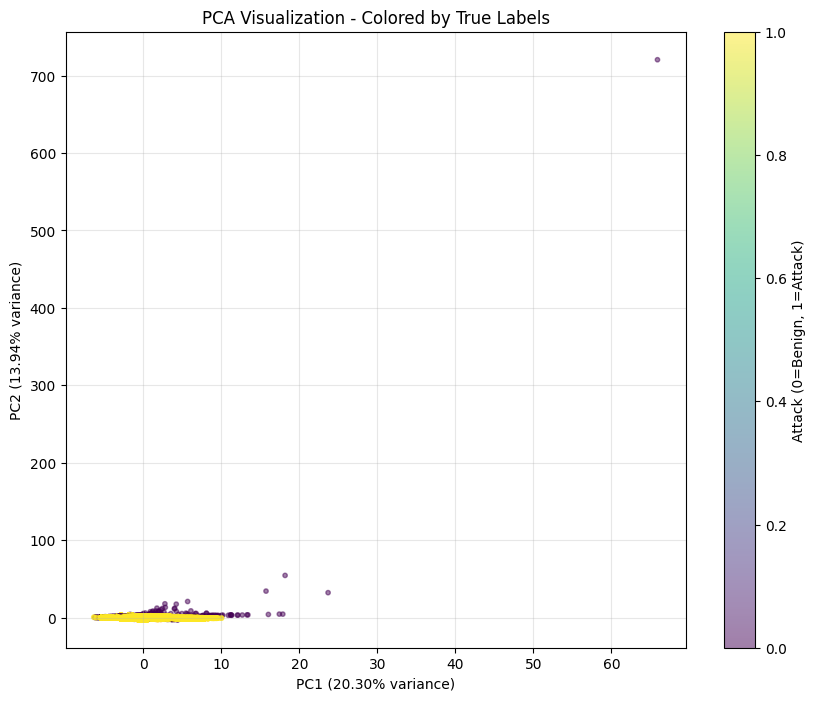

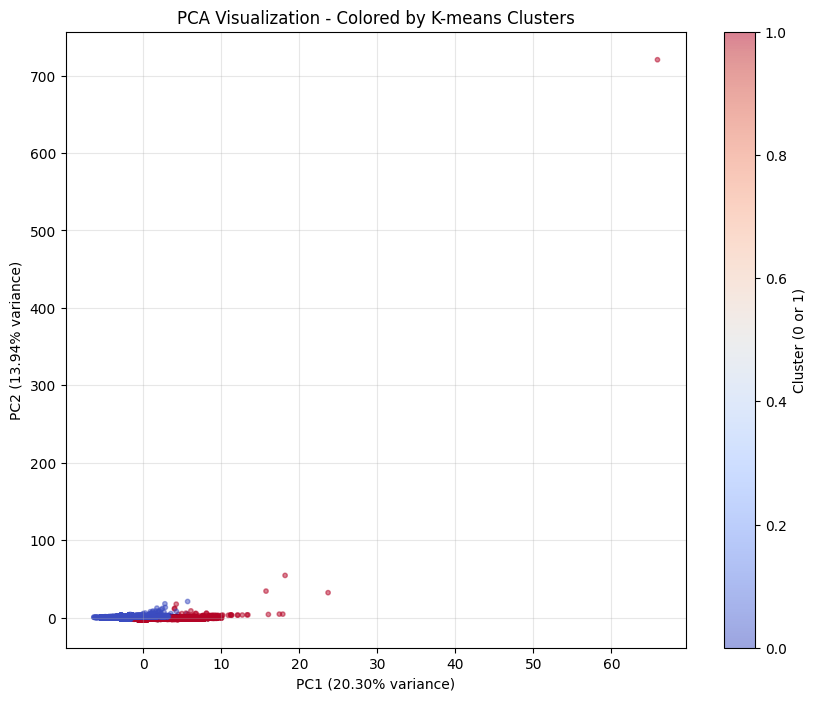

In [6]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_standardized[numeric_cols])

# Add PCA components to dataframe
df_standardized['PC1'] = pca_result[:, 0]
df_standardized['PC2'] = pca_result[:, 1]

print("="*70)
print("PCA ANALYSIS")
print("="*70)

# Show variance explained
print(f"\nVariance explained by PC1: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance explained by 2 components: {sum(pca.explained_variance_ratio_):.4f} ({sum(pca.explained_variance_ratio_)*100:.2f}%)")

# Create output directory
import os
os.makedirs('../eda/figures/multivariate', exist_ok=True)

# Plot 1: Colored by True Labels (Attack)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_standardized['PC1'], df_standardized['PC2'], 
                     c=df_standardized['Attack'], cmap='viridis', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA Visualization - Colored by True Labels')
plt.colorbar(scatter, label='Attack (0=Benign, 1=Attack)')
plt.grid(alpha=0.3)
plt.savefig('../eda/figures/multivariate/pca_true_labels.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot 2: Colored by K-means Clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(df_standardized['PC1'], df_standardized['PC2'], 
                     c=df_standardized['Cluster'], cmap='coolwarm', alpha=0.5, s=10)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.title('PCA Visualization - Colored by K-means Clusters')
plt.colorbar(scatter, label='Cluster (0 or 1)')
plt.grid(alpha=0.3)
plt.savefig('../eda/figures/multivariate/pca_clusters.png', dpi=300, bbox_inches='tight')
plt.show()


12/8/2025 - Nafisa - Multivariate Analysis

**Purpose:**  
Perform multivariate exploratory data analysis to understand relationships between features, evaluate K means(k=2) clustering, and assess dimensionality reduction techniques for potential use in modeling.

**Interpretation / Findings:** 

**Data Preparation:**
- Standardized 67 numeric features (mean=0, std=1)
- Final dataset: 60,995 rows with binary target (0=Benign, 1=Attack)

**K-means Clustering (k=2):**
- Attempted unsupervised clustering to see if data naturally separates into attack/benign groups
- Adjusted Rand Index: -0.0439 
- Clustering Accuracy: 57.38% 
- **Confusion Matrix:**
  - Cluster 0: 34,829 attacks + 4,822 benign
  - Cluster 1: 21,175 attacks + 175 benign

**PCA Analysis:**
- 2 components explain only 34% variance (66% information loss)
- Heavy overlap between attacks and benign traffic in visualizations
- Would need 17+ components for 90% variance 


**Notes for Team:**
- **Figures saved to:** `eda/figures/multivariate/`
  - `pca_true_labels.png` - PCA colored by actual attack/benign labels
  - `pca_clusters.png` - PCA colored by K-means cluster assignments

### Done with Task